In [1]:
import sys
sys.path.append("/home/export/sdurgut/scratch/alps/tracking_ALPs/")
sys.path.append('/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp')
sys.path.append('/home/export/sdurgut/scratch/alps/bkg/FORESEE')
src_path = "../"
sys.path.append(src_path)
import numpy as np
from analysis.module_VBF import TRT_length, read_data, raw_to_events
import numpy as np
import math
import matplotlib.pyplot as plt
from src.foresee import Foresee, Utility, Model
import pandas as pd
from scripts.plotting.param_space_plotting_utils import calculate_n2g
from scripts.analysis_helpers.file_helpers import ma_to_name
import sys
from pathlib import Path
PROJECT_ROOT = Path('/home/export/sdurgut/scratch/alps/tracking_ALPs')
sys.path.insert(0, str(PROJECT_ROOT / 'analysis'))
sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
def load_events(gagg_list, ma, era='run3'):

    ma_name = ma_to_name(ma)
    raw_events = read_data(
        ma_name,
        num=100000,                              # max events to load
        data_dir=str(PROJECT_ROOT / 'data/cmsrun3-csvs'),
    )
    events = raw_to_events(raw_events, gaggs=gagg_list, ma=ma, era=era)
    print(f'Loaded {len(events)} events')
    return events

In [3]:
alp_10p00 = load_events([1e-4], 10.00)


Loaded 40000 events


In [7]:
alp_10p00[0]['g1']

{'eta': np.float64(-1.2500590224700137),
 'phi': np.float64(-1.917990638298055),
 'pt': np.float64(25.621210842276547),
 'p': np.float64(48.38612886613231),
 'E': np.float64(48.386128866),
 'px': np.float64(-8.717895596),
 'py': np.float64(-24.092420829),
 'pz': np.float64(-41.045962306),
 'p_conv': array([0.76375179]),
 'conv': array([False]),
 'l_track': array([0.])}

In [5]:
def reco_alp_mass(g1, g2):
    pt1= g1['pt']
    pt2= g2['pt']
    pz1 = g1['pz']
    pz2 = g2['pz']
    eta1 = np.arcsinh(pz1/pt1)
    eta2 = np.arcsinh(pz2/pt2)
    deta = np.abs(eta1-eta2)
    phi1 = g1['phi']
    phi2 = g2['phi']
    dphi = np.abs(phi1-phi2)
    ma = np.sqrt(2 * pt1 * pt2 * (np.cosh(deta) - np.cos(dphi)))
    return ma

In [8]:
reco_alp_masses = []
for ev in alp_10p00:
    g1 = ev['g1']
    g2 = ev['g2']
    alp_mass = reco_alp_mass(g1, g2)
    reco_alp_masses.append(alp_mass)



In [9]:
reco_alp_masses

[np.float64(10.00000226648637),
 np.float64(10.000009098525155),
 np.float64(9.999956745959905),
 np.float64(10.00000120792242),
 np.float64(9.999998653704415),
 np.float64(10.00004724526315),
 np.float64(10.00004125422157),
 np.float64(10.000044615685905),
 np.float64(10.000062522275623),
 np.float64(9.99999431124869),
 np.float64(10.000009777712242),
 np.float64(10.000041972057991),
 np.float64(10.00000127806957),
 np.float64(10.00000790124168),
 np.float64(10.000006220556617),
 np.float64(10.000017101472697),
 np.float64(9.999983378096685),
 np.float64(10.000058146581122),
 np.float64(9.999997270996964),
 np.float64(9.99998214377796),
 np.float64(9.99999846327049),
 np.float64(9.999978316713428),
 np.float64(9.99999014622815),
 np.float64(9.999997544976457),
 np.float64(9.999969447849919),
 np.float64(9.99999835542561),
 np.float64(9.999992310757152),
 np.float64(9.999996390094621),
 np.float64(10.000001312517375),
 np.float64(9.999997835217084),
 np.float64(9.999995576927484),
 np.

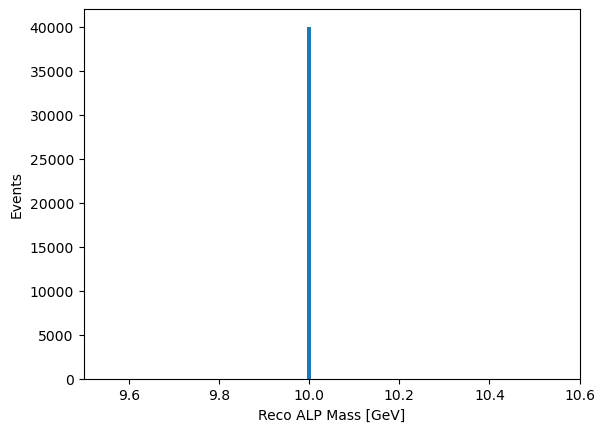

In [13]:
#make a histogram of the reco alp masses
plt.hist(reco_alp_masses, bins=np.linspace(9.55, 10.55, 100))
plt.xlabel('Reco ALP Mass [GeV]')
plt.ylabel('Events')
plt.show()

In [17]:
def diphoton_pt(g1, g2):
    pt1= g1['pt']
    pt2= g2['pt']
    pz1 = g1['pz']
    pz2 = g2['pz']
    eta1 = np.arcsinh(pz1/pt1)
    eta2 = np.arcsinh(pz2/pt2)
    deta = np.abs(eta1-eta2)
    phi1 = g1['phi']
    phi2 = g2['phi']
    dphi = np.abs(phi1-phi2) 

    diphoton_pt = np.sqrt(pt1**2 + pt2**2 + 2*pt1*pt2 * np.cos(dphi))
    return diphoton_pt 

In [18]:
diphoton_pts = []
for ev in alp_10p00:
    g1 = ev['g1']
    g2 = ev['g2']
    diphoton_pt_evt = diphoton_pt(g1, g2)
    diphoton_pts.append(diphoton_pt_evt)


In [19]:
diphoton_pts

[np.float64(35.9531522242464),
 np.float64(11.685158570061882),
 np.float64(25.35860868815929),
 np.float64(7.326254605503185),
 np.float64(19.800335751228204),
 np.float64(12.842052897060768),
 np.float64(7.454587587397666),
 np.float64(190.54362795391995),
 np.float64(57.3235825045486),
 np.float64(139.43440753898042),
 np.float64(99.67968030511902),
 np.float64(28.86696395705653),
 np.float64(21.825159232395436),
 np.float64(130.75891670174033),
 np.float64(9.766741339821017),
 np.float64(15.884049757013443),
 np.float64(43.42236086886621),
 np.float64(5.776635148108691),
 np.float64(21.81649317214037),
 np.float64(78.86015606597671),
 np.float64(15.604624230895048),
 np.float64(17.084406004401682),
 np.float64(29.0956171993669),
 np.float64(35.05444548308514),
 np.float64(3.992622796636918),
 np.float64(8.162144157530268),
 np.float64(7.754260552987714),
 np.float64(385.54925324731227),
 np.float64(7.233626267752658),
 np.float64(206.65130456992122),
 np.float64(70.98625338107871),

Text(0, 0.5, 'events')

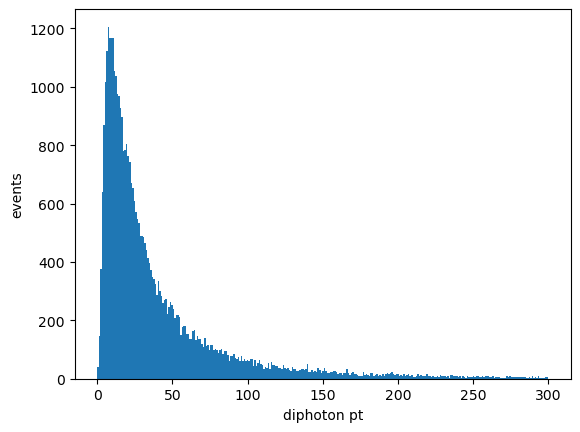

In [20]:
#plot the distributioon of diphoton_pts: 
plt.hist(diphoton_pts, bins = np.linspace(0, 300, 300))
plt.xlabel('diphoton pt')
plt.ylabel('events')

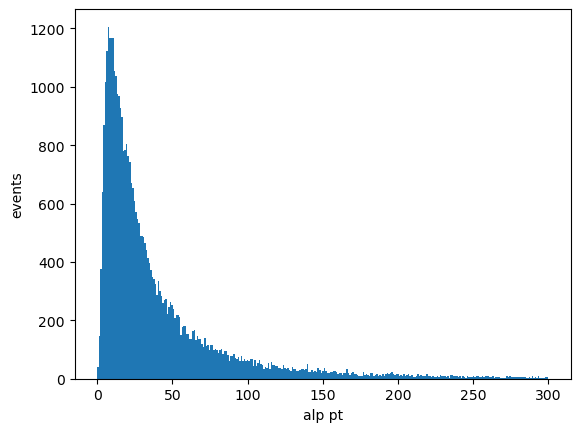

In [35]:
alp_pts = [ev['a']['pt'] for ev in alp_10p00]
plt.hist(alp_pts, bins = np.linspace(0, 300, 300))
plt.xlabel('alp pt')
plt.ylabel('events')
plt.show()

In [21]:
alp_10p00[0]

{'a': {'eta': np.float64(-1.4371748847019996),
  'phi': np.float64(-1.828612684278528),
  'pt': np.float64(35.953152224231104),
  'p': np.float64(79.93080975253592),
  'E': np.float64(80.55392227),
  'px': np.float64(-9.1669640918),
  'py': np.float64(-34.764866233),
  'pz': np.float64(-71.388410774),
  'l': array([3.17081676e-08])},
 'g1': {'eta': np.float64(-1.2500590224700137),
  'phi': np.float64(-1.917990638298055),
  'pt': np.float64(25.621210842276547),
  'p': np.float64(48.38612886613231),
  'E': np.float64(48.386128866),
  'px': np.float64(-8.717895596),
  'py': np.float64(-24.092420829),
  'pz': np.float64(-41.045962306),
  'p_conv': array([0.76375179]),
  'conv': array([False]),
  'l_track': array([0.])},
 'g2': {'eta': np.float64(-1.766780719204365),
  'phi': np.float64(-1.6128488961887626),
  'pt': np.float64(10.681889037774857),
  'p': np.float64(32.16779340441702),
  'E': np.float64(32.167793404),
  'px': np.float64(-0.44906849586),
  'py': np.float64(-10.672445404),
  '

In [22]:
alp_disps=[]
for ev in alp_10p00:
    alp_disp = ev['a']['l']
    alp_disps.append(alp_disp)

In [31]:
alp_disps = [float(alp_disps[i]) for i in range(len(alp_disps))]

/tmp/ipykernel_3641467/2326595971.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  alp_disps = [float(alp_disps[i]) for i in range(len(alp_disps))]


In [32]:
alp_disps

[3.1708167566132555e-08,
 4.4528073213688585e-08,
 1.0955835184746397e-08,
 5.412117496980487e-07,
 2.5579998022485695e-08,
 5.997196894946698e-09,
 4.194869899038111e-09,
 1.7468286492432522e-07,
 3.679117685546109e-08,
 6.36180708100329e-08,
 9.710007222990393e-08,
 7.179408660792514e-08,
 1.861914025946543e-08,
 6.858870683544734e-08,
 4.652336025725743e-08,
 7.607046162291013e-09,
 1.722549663207793e-08,
 1.9316841705188687e-08,
 1.5656309839411938e-08,
 5.8336555332284516e-08,
 9.401084028623386e-08,
 3.580048841627353e-08,
 2.4233390516939656e-08,
 2.804450395693674e-07,
 4.602128521481149e-07,
 3.1711802336904366e-08,
 1.1950212578949747e-08,
 1.5608286788969832e-07,
 1.5980985290662603e-08,
 2.406845617254884e-07,
 2.863978147799114e-08,
 2.717343955957032e-08,
 8.401885908446583e-08,
 3.998189568849393e-09,
 3.4186914172491106e-08,
 1.0795974503304732e-08,
 8.892768959619764e-08,
 5.995201759885371e-08,
 3.98756519539122e-08,
 4.069848150588637e-08,
 6.453676419852973e-08,
 7.

In [33]:
max(alp_disps)

2.309539071403711e-06

Text(0, 0.5, 'events')

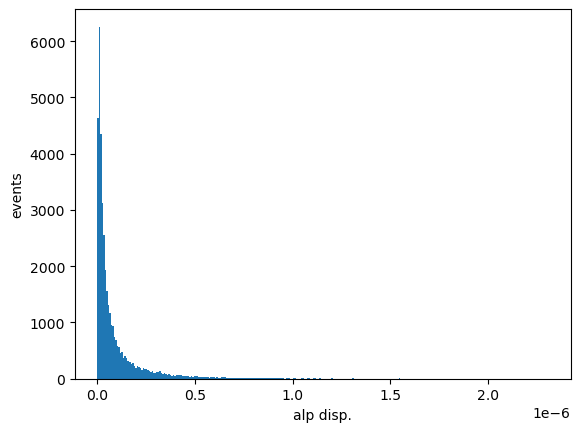

In [34]:
plt.hist(alp_disps, bins = np.linspace(0, max(alp_disps), 300))
plt.xlabel('alp disp.')
plt.ylabel('events')